In [38]:
# import packages to compile the data
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [39]:
#open point datafile
ptsPath = '/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Shp/topoWork/compoundLazAdcpPts.shp'
ptsDf = gpd.read_file(ptsPath)
ptsDf.head()

/home/hatari/.local/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


,ELEVATION1,geometry
0,147.090836,POINT Z (697309.012 4345800.389 0)
1,147.093323,POINT Z (697309.347 4345800.108 0)
2,147.097473,POINT Z (697309.683 4345799.827 0)
3,147.101761,POINT Z (697310.018 4345799.546 0)
4,147.137207,POINT Z (697310.353 4345799.265 0)


<AxesSubplot: >

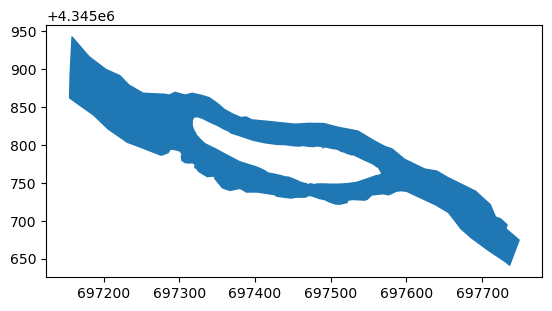

In [40]:
#open the river channel shapefile
riverChannelPath = '/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Shp/topoWork/riverChannel2023fromGoogleBuffer1m.shp'
riverChannelDf = gpd.read_file(riverChannelPath)
riverChannelDf.plot()


In [41]:
#first we create a column where all points have a value of 1 meaning that they are outside the channel
ptsDf['ptsType'] = 1
ptsDf.head()

,ELEVATION1,geometry,ptsType
0,147.090836,POINT Z (697309.012 4345800.389 0),1
1,147.093323,POINT Z (697309.347 4345800.108 0),1
2,147.097473,POINT Z (697309.683 4345799.827 0),1
3,147.101761,POINT Z (697310.018 4345799.546 0),1
4,147.137207,POINT Z (697310.353 4345799.265 0),1


In [42]:
#we assign a value of 2 for points inside the river channel
ptsDf.loc[ptsDf.within(riverChannelDf.iloc[0].geometry), 'ptsType'] = 2


<AxesSubplot: >

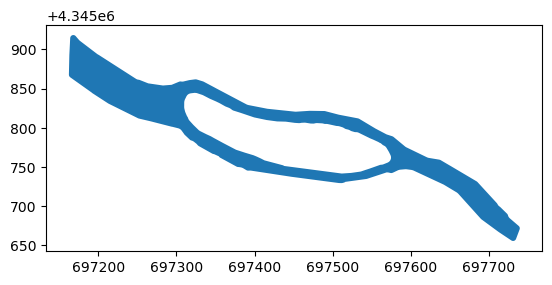

In [43]:
#open the river channel shapefile
mainChannelPath = '/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Shp/topoWork/riverChannel2023fromGoogle_MainChannel.shp'
mainChannelDf = gpd.read_file(mainChannelPath)
mainChannelDf.plot()

In [44]:
#we assign a value of 3 for points inside the main channel
ptsDf.loc[ptsDf.within(mainChannelDf.iloc[0].geometry), 'ptsType'] = 3

<AxesSubplot: >

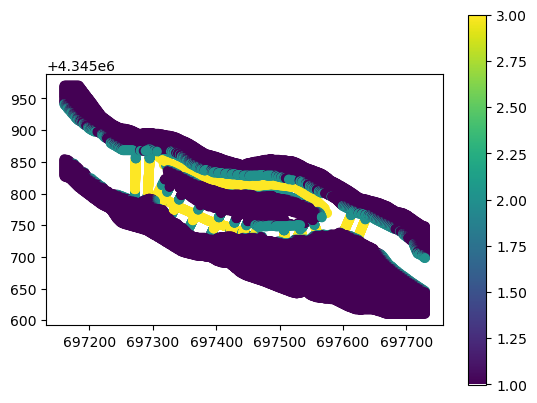

In [45]:
ptsDf.plot(column='ptsType', legend=True)

(4345740.449339061, 4345843.467398324)

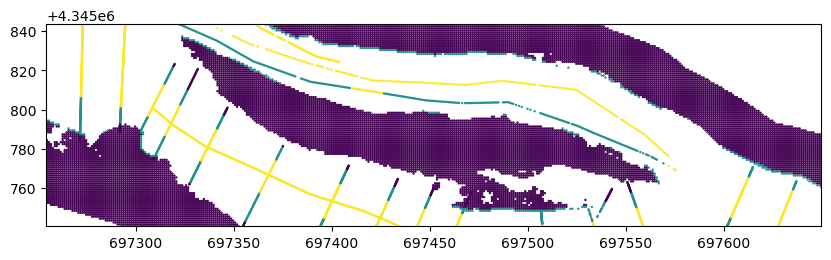

In [46]:
riverBounds = riverChannelDf.total_bounds
fig, ax = plt.subplots(figsize=(10,8))
ptsDf.plot(column='ptsType', ax=ax, markersize=0.5)
offset=100
ax.set_xlim(riverBounds[0]+offset,riverBounds[2]-offset)
ax.set_ylim(riverBounds[1]+offset,riverBounds[3]-offset)


In [47]:
#we complete the dataframe with the X and Y values
ptsDf['Easting'] = ptsDf.geometry.x
ptsDf['Northing'] = ptsDf.geometry.y
ptsDf.head()

,ELEVATION1,geometry,ptsType,Easting,Northing
0,147.090836,POINT Z (697309.012 4345800.389 0),3,697309.011790,4.345800e+06
1,147.093323,POINT Z (697309.347 4345800.108 0),3,697309.347168,4.345800e+06
2,147.097473,POINT Z (697309.683 4345799.827 0),3,697309.682546,4.345800e+06
3,147.101761,POINT Z (697310.018 4345799.546 0),3,697310.017924,4.345800e+06
4,147.137207,POINT Z (697310.353 4345799.265 0),3,697310.353301,4.345799e+06


In [48]:
# Machine learning model construction
# import required packages
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [49]:
#define the two datasets
elevValues = ptsDf.iloc[:,0].values.reshape(-1,1) #because it is a single column
paramValues = ptsDf.iloc[:,2:].values

In [50]:
paramValues

array([[3.00000000e+00, 6.97309012e+05, 4.34580039e+06],
       [3.00000000e+00, 6.97309347e+05, 4.34580011e+06],
       [3.00000000e+00, 6.97309683e+05, 4.34579983e+06],
       ...,
       [1.00000000e+00, 6.97727586e+05, 4.34561036e+06],
       [1.00000000e+00, 6.97728586e+05, 4.34561036e+06],
       [1.00000000e+00, 6.97729586e+05, 4.34561036e+06]])

In [51]:
# Define the scaler
elevScaler = StandardScaler().fit(elevValues)

# Scale the train set
elevValuesScaled = elevScaler.transform(elevValues)
elevValuesScaled[:5]

array([[-0.99649969],
       [-0.99608756],
       [-0.99539984],
       [-0.99468936],
       [-0.9888159 ]])

In [52]:
# Check scaler over head values
print(elevValuesScaled.mean(axis=0))
print(elevValuesScaled.std(axis=0))

[2.38688444e-15]
[1.]


In [53]:
# Define the scaler
paramScaler = StandardScaler().fit(paramValues)

# Scale the train set
paramValuesScaled = paramScaler.transform(paramValues)
paramValuesScaled[:5]

array([[ 4.72899745, -1.06941458,  0.58146882],
       [ 4.72899745, -1.06721414,  0.57801415],
       [ 4.72899745, -1.06501369,  0.57455948],
       [ 4.72899745, -1.06281324,  0.57110481],
       [ 4.72899745, -1.0606128 ,  0.56765013]])

In [54]:
# Check scaler over param values
print(paramValuesScaled.mean(axis=0))
print(paramValuesScaled.std(axis=0))

[-6.36502517e-17  1.60120071e-12 -4.48298457e-12]
[1. 1. 1.]


In [55]:
# Split over Train and Test
elevTrain, elevTest, paramTrain, paramTest = train_test_split(elevValuesScaled, paramValuesScaled, 
                                                              test_size=0.2, random_state=42)


In [56]:
# First we play around with a Multilayer Perceptro Regressor
regr = MLPRegressor(
    hidden_layer_sizes=(20,10),
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42)

regr.fit(paramTrain, elevTrain.ravel())

/home/hatari/.local/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


In [57]:
pred = regr.predict(paramTest)

print("Iteraciones:", regr.n_iter_)
print("R²:", r2_score(elevTest.ravel(), pred))
print("RMSE:", mean_squared_error(elevTest.ravel(), pred) ** 0.5)

Iteraciones: 200
R²: 0.7701427665172363
RMSE: 0.4816638162635302


In [ ]:
## Create the interpolated raster

import rasterio
from rasterio.plot import show
from shapely.geometry import Point
from rasterio.transform import from_bounds
#open dem and array

riverBufferPath = '/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Shp/topoWork/riverChannel2023fromGoogleBuffer1m.shp'
riverBufferDf = gpd.read_file(riverBufferPath)
totalBounds = [int(realValue) for realValue in riverBufferDf.total_bounds]
print(totalBounds)

In [ ]:
nRows = totalBounds[3] - totalBounds[1]
nCols = totalBounds[2] - totalBounds[0]
print(nRows, nCols)

In [ ]:
yCellCenterArray = np.arange(totalBounds[1]+0.5, totalBounds[3] + 0.5 )
xCellCenterArray = np.arange(totalBounds[0]+0.5, totalBounds[2] + 0.5 )
print(yCellCenterArray.shape,xCellCenterArray.shape)

In [ ]:
#asuming that the output raster has a resolution of 1m
interpElevs = np.zeros([nRows,nCols])
paramTupleList = []

i = 0
for row in range(nRows):
    for col in range(nCols):
        y = yCellCenterArray[row]
        x = xCellCenterArray[col]
        pointXY = Point(x,y)
        if pointXY.within(riverChannelDf.iloc[0].geometry):
            paramTuple = [2, x, y]
        else: 
            paramTuple = [1, x, y]
        paramTupleList.append(paramTuple)

        if i % 40000 == 0:
            print('processing %d cells, please be patient!'%i)
        i+=1

In [ ]:
paramTupleScaledList = paramScaler.transform(paramTupleList)

In [ ]:
# work on the matrix that converts the array in the raster
transform = from_bounds(
    totalBounds[0], totalBounds[1], totalBounds[2], totalBounds[3],
    nCols,nRows
) 
transform

In [ ]:
demMeta = {
    'driver': 'GTiff',
    'dtype': 'float32',
    'nodata': -9999,
    'width': nCols,
    'height': nRows,
    'count': 1,
    'crs': riverBufferDf.crs,
    'transform':transform
}

In [ ]:
interpElevList = regr.predict(paramTupleScaledList)
interpElevListInversed = elevScaler.inverse_transform(interpElevList.reshape(-1,1))
interpElevListInversed[-5:]

In [ ]:
interpHeadsArray = interpElevListInversed.reshape([nRows,nCols])
interpHeadsArray = np.flipud(interpHeadsArray)
plt.imshow(interpHeadsArray)

In [ ]:
interpRaster = rasterio.open('/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Rst/topoWork/riverBathymetry_MLP.tif','w',**demMeta)

interpRaster.write(interpHeadsArray,1)

interpRaster.close()

In [58]:
# Since the results are not promising we apply a Random Forest Regressor
from sklearn.ensemble import ExtraTreesRegressor

regrTree = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

regrTree.fit(paramTrain, elevTrain.ravel())

elevPredict = regrTree.predict(paramTest)

print("R²:", r2_score(elevTest.ravel(), elevPredict))
print("RMSE:", mean_squared_error(elevTest.ravel(), elevPredict) ** 0.5)

R²: 0.9914713894099499
RMSE: 0.09277993785668269


In [59]:
# That is promising, the error has decreased from 0.496 to 0.0909 before rescaling
# get the inverse for the test and predicted elevations
elevPredictedInversed = elevScaler.inverse_transform(elevPredict.reshape(-1,1))
elevTestInversed = elevScaler.inverse_transform(elevTest.reshape(-1,1))

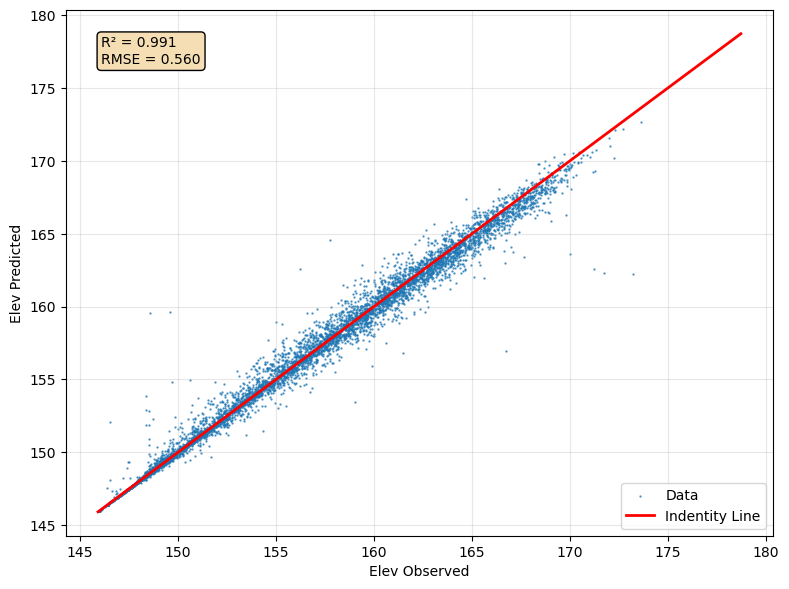

In [60]:
# Create single subplot
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
ax.scatter(elevTestInversed, elevPredictedInversed, alpha=0.7, s=0.5, label='Data')

# Regression line
x_line = np.linspace(elevValues.min(), elevValues.max(), 100).reshape(-1, 1)
ax.plot(x_line, x_line, color='red', linewidth=2, label='Indentity Line')

# Calculate metrics
r2 = r2_score(elevTestInversed, elevPredictedInversed)
rmse = np.sqrt(mean_squared_error(elevTestInversed, elevPredictedInversed))

# Add metrics as text
metrics_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}'
ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

ax.set_xlabel('Elev Observed')
ax.set_ylabel('Elev Predicted')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
## Create the interpolated raster

import rasterio
from rasterio.plot import show
from shapely.geometry import Point
from rasterio.transform import from_bounds
#open dem and array

riverBufferPath = '/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Shp/topoWork/riverChannel2023fromGoogleBuffer1m.shp'
riverBufferDf = gpd.read_file(riverBufferPath)
totalBounds = [int(realValue) for realValue in riverBufferDf.total_bounds]
print(totalBounds)

[697154, 4345640, 697749, 4345943]


In [62]:
nRows = totalBounds[3] - totalBounds[1]
nCols = totalBounds[2] - totalBounds[0]
print(nRows, nCols)

303 595


In [63]:
yCellCenterArray = np.arange(totalBounds[1]+0.5, totalBounds[3] + 0.5 )
xCellCenterArray = np.arange(totalBounds[0]+0.5, totalBounds[2] + 0.5 )
print(yCellCenterArray.shape,xCellCenterArray.shape)

(303,) (595,)


In [64]:
#asuming that the output raster has a resolution of 1m
interpElevs = np.zeros([nRows,nCols])
paramTupleList = []

i = 0
for row in range(nRows):
    for col in range(nCols):
        y = yCellCenterArray[row]
        x = xCellCenterArray[col]
        pointXY = Point(x,y)
        if pointXY.within(riverChannelDf.iloc[0].geometry):
            paramTuple = [2, x, y]
        else: 
            paramTuple = [1, x, y]
        paramTupleList.append(paramTuple)

        if i % 40000 == 0:
            print('processing %d cells, please be patient!'%i)
        i+=1


processing 0 cells, please be patient!
processing 40000 cells, please be patient!
processing 80000 cells, please be patient!
processing 120000 cells, please be patient!
processing 160000 cells, please be patient!


In [65]:
paramTupleScaledList = paramScaler.transform(paramTupleList)

In [66]:
# work on the matrix that converts the array in the raster
transform = from_bounds(
    totalBounds[0], totalBounds[1], totalBounds[2], totalBounds[3],
    nCols,nRows
) 
transform

Affine(1.0, 0.0, 697154.0,
       0.0, -1.0, 4345943.0)

In [67]:
demMeta = {
    'driver': 'GTiff',
    'dtype': 'float32',
    'nodata': -9999,
    'width': nCols,
    'height': nRows,
    'count': 1,
    'crs': riverBufferDf.crs,
    'transform':transform
}

In [68]:
interpElevList = regrTree.predict(paramTupleScaledList)
interpElevListInversed = elevScaler.inverse_transform(interpElevList.reshape(-1,1))
interpElevListInversed[-5:]

array([[161.70306],
       [161.70306],
       [161.70306],
       [161.70306],
       [161.70306]])

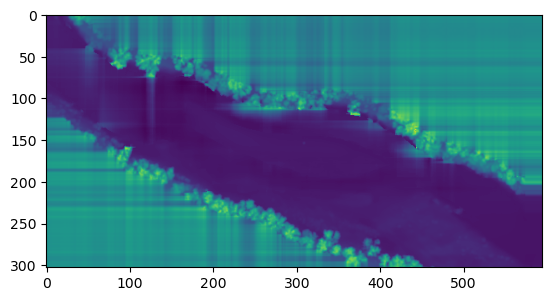

In [69]:
interpHeadsArray = interpElevListInversed.reshape([nRows,nCols])
interpHeadsArray = np.flipud(interpHeadsArray)
plt.imshow(interpHeadsArray)

In [71]:
interpRaster = rasterio.open('/mnt/c/Users/saulm/Documents/GitHub/theisNashEnvironmentalMonitoringModelingSite/l1processedData/Rst/topoWork/riverBathymetry_RF.tif','w',**demMeta)

interpRaster.write(interpHeadsArray,1)

interpRaster.close()